# Thin film Lithium Niobate Electro-Optic Modulator using Tidy3D

In this example, we will simulate a thin-film lithium niobate electro-optic modulator based on Pockels effect. The device is based on the work of `*Ying Li et al.*, “High-Performance Mach–Zehnder Modulator Based on Thin-Film Lithium Niobate with Low Voltage-Length Product,” *ACS Omega* 2023, 8 (10), 9644–9651.` DOI: [10.1021/acsomega.3c00310](https://pubs.acs.org/doi/10.1021/acsomega.3c00310).

We start by calculating the propagating modes of the TFLN waveguide and the coplanar (CPW) transmission line using [mode simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

Finally, we calculate the electro-optic overlap and predict the Vπ·L figure of merit.

You can check [here](https://docs.flexcompute.com/projects/photonforge/en/latest/examples/EO-MZM.html) the same model, along with the full chip layout integrated with a foundry PDK, using [Photonforge](https://www.flexcompute.com/photonforge/), our photonic design automation tool.

<img src="img/TFLN_EOM_Tidy3D.png" width=600 alt="Schematic of the grating coupler">



### Workflow Overview

[1.](#1) Define the thin-film lithium niobate waveguide geometry and solve for the optical TE mode using [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

[2.](#2) Build the CPW transmission line in the same cross-section and compute the RF mode.

[3.](#3) Normalize the RF field to 1 V across the electrodes, evaluate the electro-optic overlap, and estimate Vπ·L.


In [1]:
# Core simulation and plotting libraries
import numpy as np
import tidy3d as td

# RF utilities for impedance and port definitions
import tidy3d.plugins.microwave as mw
import tidy3d.plugins.smatrix as sm
from matplotlib import pyplot as plt
from tidy3d import web
from tidy3d.plugins.mode import ModeSolver

# Suppress verbose logs to keep the notebook output clear
td.config.logging_level = "ERROR"

## Optical Waveguide Geometry

In [2]:
eff_inf = 1e3  # Large extent to emulate semi-infinite regions

opt_wavelength = 1.55
freq_opt = td.C_0 / opt_wavelength


# Optical materials: SiO2 cladding and TFLN core
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)

# Ridge geometry parameters from the reference design
sidewall_angle = 15
core_thickness = 0.2
core_width = 3.0
slab_thickness = 0.2
plane_size = 8
plane_limits = (-1.5, 1.9)
plane_height = 3.4


ridge = td.Structure(
    name="ridge",
    geometry=td.Box(
        center=(0.0, 0.0, -slab_thickness / 2), size=(eff_inf, eff_inf, slab_thickness)
    ),
    medium=LiNbO3,
)

core = td.Structure(
    geometry=td.PolySlab(
        sidewall_angle=sidewall_angle * np.pi / 180,
        reference_plane="top",
        slab_bounds=[0, core_thickness],
        vertices=[
            [-eff_inf, -core_width / 2],
            [eff_inf, -core_width / 2],
            [eff_inf, core_width / 2],
            [-eff_inf, core_width / 2],
        ],
    ),
    name="core",
    medium=LiNbO3,
)


grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=opt_wavelength)

sim_opt = td.Simulation(
    size=(10.0, plane_size, plane_height),
    run_time=1e-12,
    medium=SiO2,
    structures=[ridge, core],
    grid_spec=grid_spec,
)

### Creating the [ModSolver]() object and run mode simulation.

<Axes: title={'center': 'cross section at x=0.00 (μm)'}, xlabel='y (μm)', ylabel='z (μm)'>

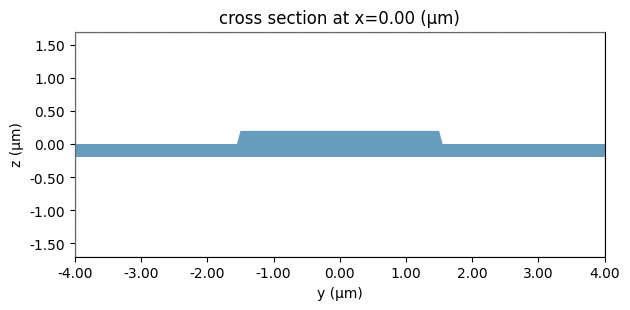

In [3]:
## Creating the ModeSolver

mode_spec = td.ModeSpec(num_modes=5)

plane_size = (0, sim_opt.bounding_box.size[1], sim_opt.bounding_box.size[2])
plane = sim_opt.bounding_box.updated_copy(size=plane_size)

mode_solver_opt = ModeSolver(simulation=sim_opt, freqs=[freq_opt], mode_spec=mode_spec, plane=plane)

mode_solver_opt.plot()

In [4]:
mode_data_opt = web.run(mode_solver_opt, task_name="TFLN-opt_mode", folder_name="TFLN-VPI")

11:59:38 -03 Created task 'TFLN-opt_mode' with resource_id                      
             'mo-d7687704-b36c-40bc-9e28-ca4c65db8e72' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=734769;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=250938;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\taskId]8;;\]8;id=734769;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\=]8;;\]8;id=605385;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\mo]8;;\]8;id=734769;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\-d7687704-b36c-]8;;\
             ]8;id=734769;https://tidy3d.simulation.cloud/workbench?taskId=mo-d7687704-b36c-40bc-9e28-ca4c65db8e72\40bc-9e28-ca4c65db8e72']8;;\.

             Task folder: ]8;id=29615;https://tidy3d.simulation.cloud/folders/folder-8992deaf-7bd2-4439-9603-4a345bb23569\'TFLN-VPI']8;;\.

Output()

11:59:42 -03 Estimated FlexCredit cost: 0.004. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

11:59:43 -03 status = success

Output()

11:59:54 -03 loading simulation from simulation_data.hdf5

We can now visualize and inspect the optical modes.

wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
1.934145e+14 0                 1.55  1.851449    0.0          0.999711   
             1                 1.55  1.813747    0.0          0.997992   
             2                 1.55  1.762851    0.0          0.004845   
             3                 1.55  1.753301    0.0          0.978658   
             4                 1.55  1.722364    0.0          0.030296   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.934145e+14 0                 0.988385        0.869531   1.395676  
             1                 0.955486        0.874227   1.537450  
             2                 0.775261        0.987734   2.170106  
             3                 0.909164        0.881780   1.840836  
             4                 0.785301        0.951572   2.260011

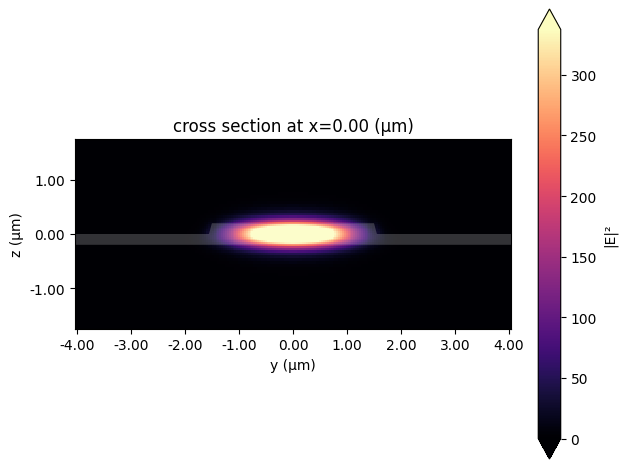

In [5]:
mode_solver_opt.plot_field("E", "abs^2", mode_index=0)
mode_data_opt.to_dataframe()

## RF CPW Transmission Line

Next, we define the CPW geometry and again use [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) to calculate the RF mode.

In [6]:
rf_freqs = np.linspace(1e9, 65e9, 20)

# RF mediums

si_rf = td.Medium(permittivity=11.7)
sio2_rf = td.Medium(permittivity=3.9)
air_rf = td.Medium()
tfln_rf = td.AnisotropicMedium(
    xx=td.Medium(permittivity=44), yy=td.Medium(permittivity=27.9), zz=td.Medium(permittivity=44)
)
metal = td.LossyMetalMedium(
    frequency_range=(100000000.0, 100000000000.0),
    conductivity=41,
    fit_param=td.SurfaceImpedanceFitterParam(
        max_num_poles=16,
    ),
)

tfln_thickness = 0.2
sio2_thickness = 7
metal_thickness = 0.9
tfln_height = (
    4.7 + tfln_thickness / 2
)  # Distance between the center of the TFLN from the Si substrate

cpw_thickness = 0.9
cpw_center = sio2_thickness / 2 - cpw_thickness / 2
cpw_width = 10
cpw_gap = 4

cpw_left = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, -cpw_width / 2 - cpw_gap, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

cpw_right = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, cpw_width / 2 + cpw_gap, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, eff_inf, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

cpw_center = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -cpw_width / 2, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, cpw_width / 2, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)


sio2_slab = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, sio2_thickness)), medium=sio2_rf
)
tfln_slab = td.Structure(
    geometry=td.Box(
        center=(0, 0, -sio2_thickness / 2 + tfln_height), size=(eff_inf, eff_inf, tfln_thickness)
    ),
    medium=tfln_rf,
)

si_substrate = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, -eff_inf), rmax=(eff_inf, eff_inf, -3.5)),
    medium=si_rf,
)

air_gap = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, 3.5), rmax=(eff_inf, eff_inf, eff_inf)),
    medium=air_rf,
)

Since the RF wavelength is much larger than the geometric features, we use a [LayerRefinementSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LayerRefinementSpec.html) at the CPW to automatically enhance the mesh and better resolve its corners.

In [7]:
# Define RF frequency range from 1 GHz to 65 GHz
rf_freqs = np.linspace(1e9, 65e9, 20)


# Define Layer refinement spec
lr_spec = td.LayerRefinementSpec.from_structures(
    structures=[cpw_center, cpw_left, cpw_right],
    min_steps_along_axis=5,
    corner_refinement=td.GridRefinement(dl=cpw_thickness / 10, num_cells=5),
    refinement_inside_sim_only=False,
)

# Overall grid specification
grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=100,
    wavelength=td.C_0 / max(rf_freqs),
    layer_refinement_specs=[lr_spec],
)

sim_rf_size = (25, 138, 150)

sim_rf = td.Simulation(
    size=sim_rf_size,
    structures=[sio2_slab, tfln_slab, si_substrate, air_gap, cpw_left, cpw_right, cpw_center],
    grid_spec=grid_spec,
    run_time=1e-12,
)

Now, we can inspect the grid.

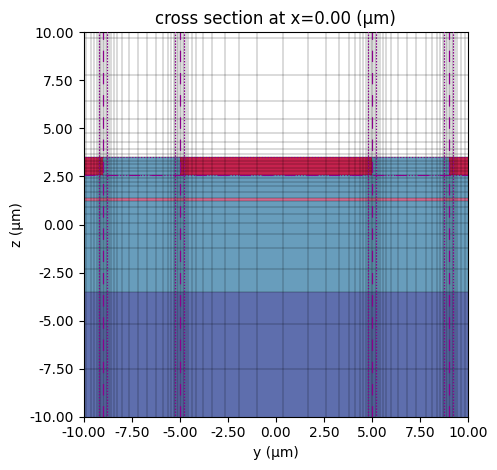

In [8]:
ax = sim_rf.plot(x=0)
sim_rf.plot_grid(x=0, ax=ax)
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

plt.show()

Now, we define a [WavePort](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.smatrix.WavePort.html) object containing a [current](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.CurrentIntegralAxisAligned.html) integration path defined around the CPW signal, and a [voltage](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.VoltageIntegralAxisAligned.html) integration path from the signal to ground to calculate impedance.


In [9]:
# Define current integration path (loop)
I_int = mw.CurrentIntegralAxisAligned(
    center=cpw_center.geometry.center,
    size=(
        0,
        cpw_width + cpw_gap,
        5 * cpw_thickness,
    ),
    sign="+",
)
# Define voltage integration path (line)
V_int = mw.VoltageIntegralAxisAligned(
    center=(0, cpw_width / 2 + cpw_gap / 2, cpw_center.geometry.center[2]),
    size=(0, cpw_gap, 0),
    sign="-",
)

# Define wave ports
WP1 = sm.WavePort(
    center=cpw_center.geometry.center,
    size=(0, sim_rf.size[1], sim_rf.size[2]),
    mode_spec=td.ModeSpec(target_neff=2.2),
    direction="+",
    name="WP1",
    current_integral=I_int,
    voltage_integral=V_int,
)

Finally, we can use our [WavePort](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.smatrix.WavePort.html) object to automatically configure the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) based on the RF simulation model.


In [10]:
# Obtain mode solver from wave port
mode_solver_rf = WP1.to_mode_solver(simulation=sim_rf, freqs=rf_freqs)

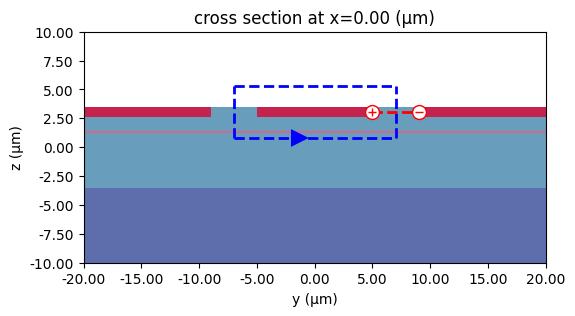

In [11]:
# Plot V and I integration paths
fig, ax = plt.subplots(figsize=(10, 3))
mode_solver_rf.plot(ax=ax)
I_int.plot(x=0, ax=ax)
V_int.plot(x=0, ax=ax)
ax.set_xlim(-20, 20)
ax.set_ylim(-10, 10)
plt.show()

In [12]:
mode_data_rf = web.run(mode_solver_rf, task_name="CPW mode solver", path="data/WP1_mode_data.hdf5")

11:59:56 -03 Created task 'CPW mode solver' with resource_id                    
             'mo-2291d686-25b0-4507-bbf9-ee62b720fbba' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=108546;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=544536;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\taskId]8;;\]8;id=108546;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\=]8;;\]8;id=952698;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\mo]8;;\]8;id=108546;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\-2291d686-25b0-]8;;\
             ]8;id=108546;https://tidy3d.simulation.cloud/workbench?taskId=mo-2291d686-25b0-4507-bbf9-ee62b720fbba\4507-bbf9-ee62b720fbba']8;;\.

             Task folder: ]8;id=893179;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

11:59:58 -03 Estimated FlexCredit cost: 0.006. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

12:00:00 -03 status = success

Output()

12:00:13 -03 loading simulation from data/WP1_mode_data.hdf5

We can now use the built-in [ImpedanceCalculator](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.ImpedanceCalculator.html) to calculate and visualize the impedance results.


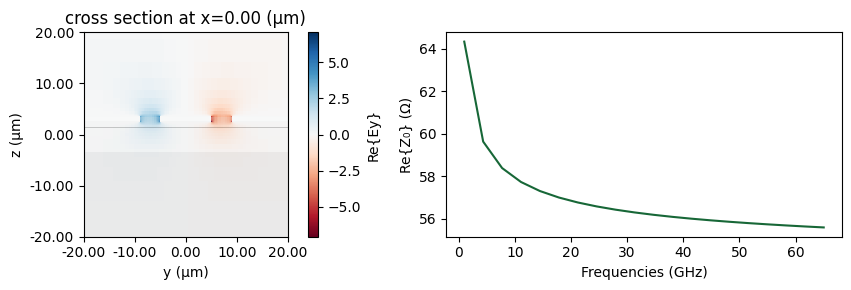

In [13]:
# Calculate Z0
Z0_mode = np.conjugate(
    mw.ImpedanceCalculator(voltage_integral=V_int, current_integral=I_int).compute_impedance(
        mode_data_rf
    )
).squeeze()


fig, ax = plt.subplots(1, 2, figsize=(9, 3), tight_layout=True)

mode_solver_rf.plot_field("Ey", "real", f=rf_freqs[0].item(), robust=False, ax=ax[0])
ax[0].set_xlim(-20, 20)
ax[0].set_ylim(-20, 20)

ax[1].plot(Z0_mode.f * 1e-9, Z0_mode.real)
_ = ax[1].set(xlabel="Frequencies (GHz)", ylabel="Re{Z₀} (Ω)")

## Computation of Vπ·L

Next, we run a similar mode simulation, this time adding the TFLN waveguides beneath the CPW gaps. We then monitor the RF fields at the waveguides and calculate the index change due to the Pockels effect.

In [14]:
delta_z = tfln_slab.geometry.center[2] - ridge.geometry.center[2]

waveguide_r = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="ridge_r",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="core_r",
        medium=tfln_rf,
    ),
]

waveguide_l = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="ridge_l",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="core_l",
        medium=tfln_rf,
    ),
]

override_region = td.MeshOverrideStructure(
    geometry=td.Box(
        size=(eff_inf, eff_inf, slab_thickness + core_thickness),
        center=(0, 0, tfln_slab.geometry.center[2] + tfln_thickness / 2),
    ),
    dl=(None, None, 0.01),
)

gap_center = cpw_center.geometry.center[1] + cpw_width / 2 + cpw_gap / 2

override_region_gap_l = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, gap_center, 0)),
    dl=(None, 0.01, None),
)

override_region_gap_r = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, -gap_center, 0)),
    dl=(None, 0.01, None),
)


grid_spec_vpi = grid_spec.updated_copy(
    override_structures=[override_region, override_region_gap_l, override_region_gap_r]
)
sim_vpi = sim_rf.updated_copy(
    structures=[sio2_slab, si_substrate, air_gap, cpw_left, cpw_right, cpw_center]
    + waveguide_r
    + waveguide_l,
    grid_spec=grid_spec_vpi,
)

(4.0, 10.0)

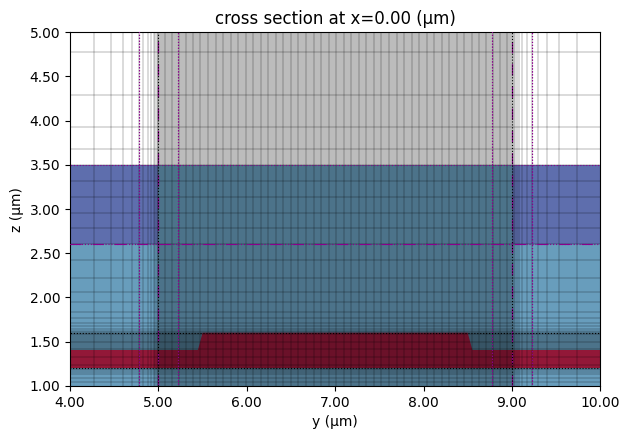

In [15]:
mzm_solver = ModeSolver(
    simulation=sim_vpi,
    plane=mode_solver_rf.plane,
    mode_spec=td.ModeSpec(num_modes=1, target_neff=2.2),
    freqs=rf_freqs,
)


ax = mzm_solver.plot()
mzm_solver.plot_grid(ax=ax)
ax.set_ylim(1, 5)
ax.set_xlim(4, 10)

In [16]:
mzm_mode_data = web.run(mzm_solver, task_name="MZM mode solver", path="data/MZM_mode_data.hdf5")

12:00:15 -03 Created task 'MZM mode solver' with resource_id                    
             'mo-2cc0f904-09e7-4efd-a998-13eaae14f231' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=776406;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=918486;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\taskId]8;;\]8;id=776406;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\=]8;;\]8;id=657276;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\mo]8;;\]8;id=776406;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\-2cc0f904-09e7-]8;;\
             ]8;id=776406;https://tidy3d.simulation.cloud/workbench?taskId=mo-2cc0f904-09e7-4efd-a998-13eaae14f231\4efd-a998-13eaae14f231']8;;\.

             Task folder: ]8;id=753555;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

12:00:18 -03 Estimated FlexCredit cost: 0.015. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

12:00:20 -03 status = success

Output()

12:00:39 -03 loading simulation from data/MZM_mode_data.hdf5

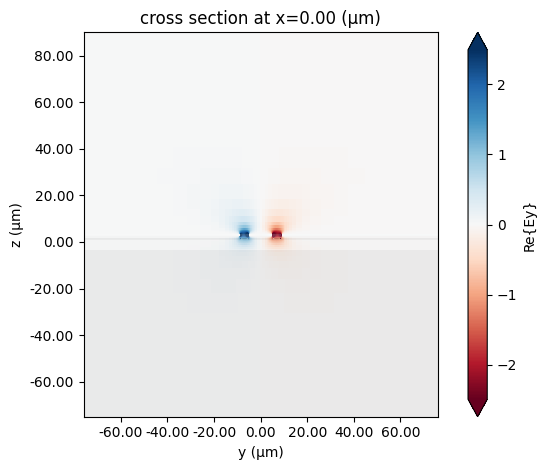

In [17]:
_ = mzm_solver.plot_field("Ey", "real", f=rf_freqs[0], mode_index=0, robust=True)

Visualizing the results.

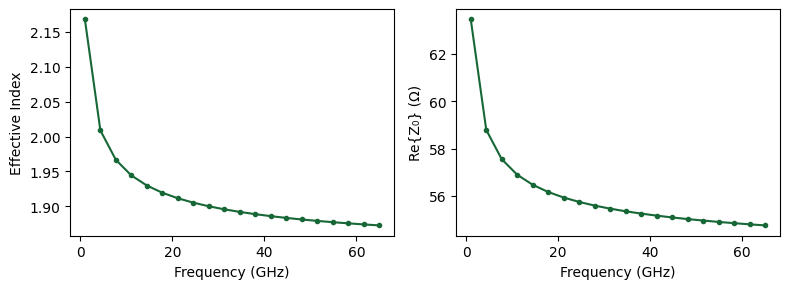

In [18]:
n_eff = mzm_solver.data.n_eff.isel(mode_index=0).values

# Calculate Z0
Z0_mzm = np.conjugate(
    mw.ImpedanceCalculator(voltage_integral=V_int, current_integral=I_int).compute_impedance(
        mzm_mode_data
    )
).squeeze()

fig, ax = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

ax[0].plot(rf_freqs * 1e-9, n_eff, ".-")
ax[0].set(ylabel="Effective Index", xlabel="Frequency (GHz)")

ax[1].plot(rf_freqs * 1e-9, np.real(Z0_mzm), ".-")
_ = ax[1].set(ylabel="Re{Z₀} (Ω)", xlabel="Frequency (GHz)")

To calculate the Pockels effect, we apply an electric field along the LiNbO₃ cut direction to perturb the optical medium. First, we normalize the field by the applied voltage and shift its coordinates so they align with the optical simulation, where the dielectric waveguide is centered at y = 0.

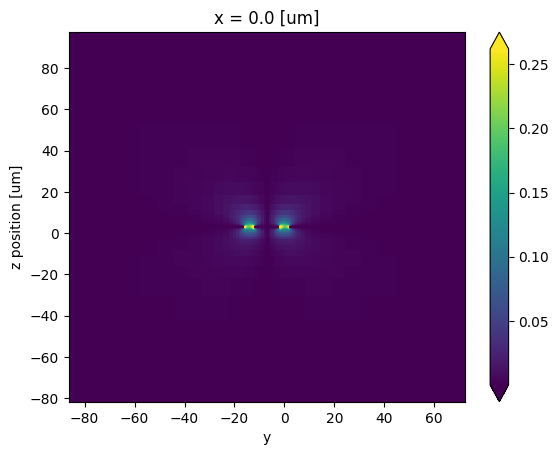

In [19]:
v0 = WP1.voltage_integral.compute_voltage(mzm_solver.data)
ey_norm = (mzm_solver.data.Ey / v0).isel(f=0, mode_index=0, drop=True).abs

offset = cpw_width / 2 + cpw_gap / 2
ey_norm = ey_norm.assign_coords(y=ey_norm.y - offset)

ey_norm.isel(x=0).transpose("z", "y").plot(robust=True)
# _ = plt.gca().set(xlim=(-gap, gap), ylim=(-1, 4))

The normalized electric field is applied to the LiNbO₃ crystal along its z-axis, following the Pockels effect model:

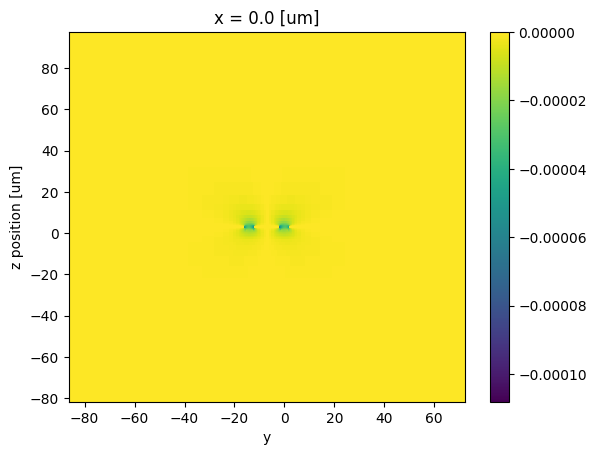

In [20]:
eps_o, eps_e, _ = (e.real for e in LiNbO3.eps_diagonal(td.C_0 / opt_wavelength))
n_e = eps_e**0.5
r33 = 30.9e-6  # μm/V

# Index variation derived from the RF field
Δn = -0.5 * n_e**3 * r33 * ey_norm

# We plot the whole domain, but the perturbation will only take effect over the LiNbO₃, not everywhere
_ = Δn.isel(x=0).transpose("z", "y").plot(robust=False)

We can now define an auxiliary function to create the perturbed medium using a [CustomAnisotropicMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomAnisotropicMedium.html) object as a function of the voltage, and return a [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) object.


In [21]:
# Use a single data point for the homogeneous directions
eps_o_array = td.SpatialDataArray(np.full((1, 1, 1), eps_o), coords={"x": [0], "y": [0], "z": [0]})


def perturbed_solver(voltage):
    perturbed_ln = td.CustomAnisotropicMedium(
        xx=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
        yy=td.CustomMedium(permittivity=(n_e + voltage * Δn) ** 2, subpixel=True),
        zz=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
    )
    perturbed_sim = sim_opt.updated_copy(
        structures=[core.updated_copy(medium=perturbed_ln), ridge.updated_copy(medium=perturbed_ln)]
    )
    ms = mode_solver_opt.updated_copy(simulation=perturbed_sim)
    return ms

Next, we create a [Batch](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.container.Batch.html) and run all mode simulations in parallel.

In [22]:
voltages = np.arange(5)

sims = {str(v): perturbed_solver(v) for v in voltages}

batch = web.Batch(simulations=sims, folder_name="perturbed_mode")

batch_data = batch.run(path_dir="batch_perturbed_mode")

Output()

12:00:49 -03 Started working on Batch containing 5 tasks.

12:00:56 -03 Maximum FlexCredit cost: 0.020 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

12:01:00 -03 Batch complete.

Output()

Finally, we can observe the variation of the waveguide mode effective index as a function of the applied voltage and calculate the Vπ·L figure of merit.

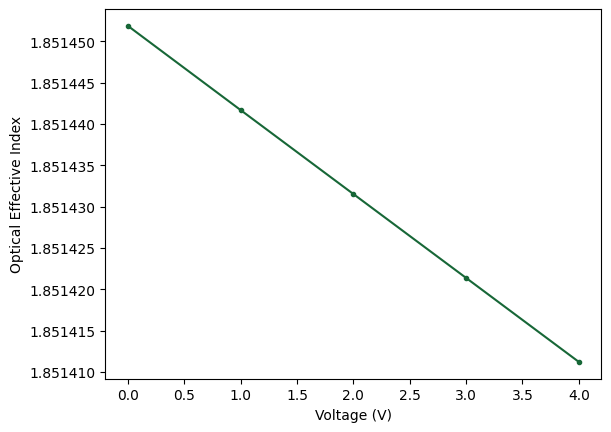

In [23]:
n_eff = [sim_data.n_eff.isel(mode_index=0, f=0).item() for sim_data in batch_data.values()]

_ = plt.plot(voltages, n_eff, ".-")
_ = plt.ticklabel_format(style="plain", useOffset=False)
plt.gca().set(xlabel="Voltage (V)", ylabel="Optical Effective Index")

plt.show()

In [24]:
# The variation is quite linear, so we simply use the largest interval
dneff_dV = abs(n_eff[-1] - n_eff[0]) / (voltages[-1] - voltages[0])

vpil = 0.5 * opt_wavelength / dneff_dV  # in V·μm"

print(f"Vπ·L (single-drive) = {vpil * 1e-4:.2f} V·cm")
print(f"Vπ·L (push-pull)    = {vpil * 1e-4 / 2:.2f} V·cm")

Vπ·L (single-drive) = 7.62 V·cm
Vπ·L (push-pull)    = 3.81 V·cm
